DATASET LOADED
Shape: (284807, 31)
Time range: 0 → 172,792

✓ Dataset sorted chronologically.

TEMPORAL SPLIT
Total observations : 284,807
Training           : 199,364
Validation         : 42,721
Test               : 42,722


,Dataset,Transactions,Fraud,Legitimate,Fraud Rate (%),Start Time,End Time
0,Train,199364,384,198980,0.192613,0.0,132928.0
1,Validation,42721,56,42665,0.131083,132929.0,151328.0
2,Test,42722,52,42670,0.121717,151328.0,172792.0



CHRONOLOGICAL CHECK
Train ends at: 132928.0
Validation starts at: 132929.0
Validation ends at: 151328.0
Test starts at: 151328.0
Test ends at: 172792.0

OVERLAP CHECK
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Total observations across splits: 284807
Original observations: 284807
✓ All observations accounted for.


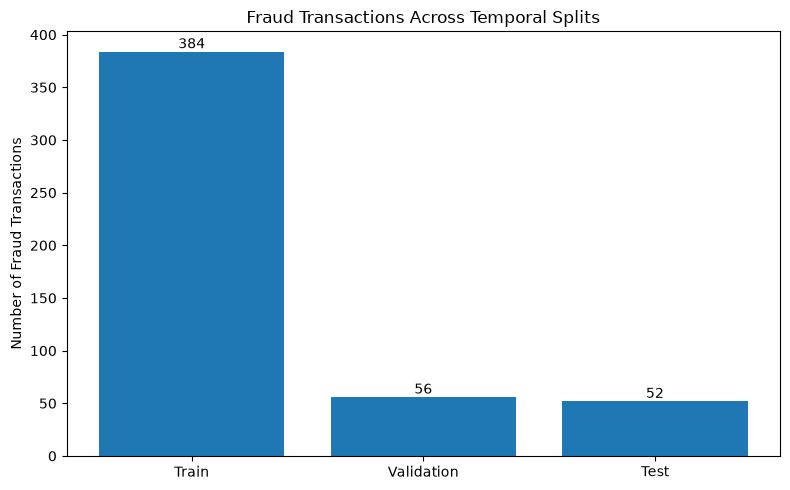

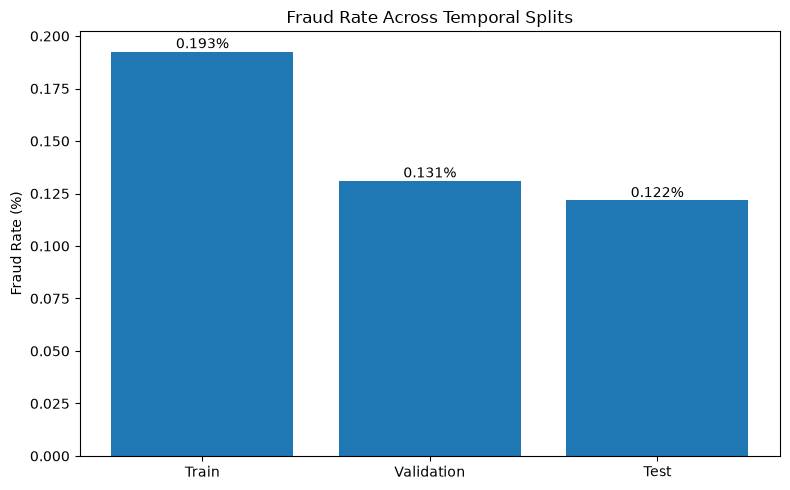


✓ Split indices saved to:
../data/temporal_split_indices.npz

PHASE 2 COMPLETE
✓ Chronological split verified
✓ No train/validation overlap
✓ No train/test overlap
✓ No validation/test overlap
✓ Split indices saved


In [1]:
# ============================================================
# CREDIT CARD FRAUD DETECTION
# PHASE 2 — TEMPORAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print(f"Shape: {df.shape}")
print(f"Time range: {df['Time'].min():,.0f} → {df['Time'].max():,.0f}")


# ============================================================
# 2. SORT BY TIME
# ============================================================

# Explicitly sort by transaction time.
# This guarantees that the split is chronological.

df = df.sort_values("Time").reset_index(drop=True)

print("\n✓ Dataset sorted chronologically.")


# ============================================================
# 3. DEFINE TEMPORAL SPLIT
# ============================================================

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = df.iloc[:train_end].copy()

validation = df.iloc[train_end:validation_end].copy()

test = df.iloc[validation_end:].copy()


# ============================================================
# 4. SPLIT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TEMPORAL SPLIT")
print("=" * 70)

print(f"Total observations : {len(df):,}")
print(f"Training           : {len(train):,}")
print(f"Validation         : {len(validation):,}")
print(f"Test               : {len(test):,}")


# ============================================================
# 5. FRAUD COUNTS
# ============================================================

def fraud_summary(data, name):

    fraud_count = int(data["Class"].sum())
    total = len(data)
    fraud_rate = data["Class"].mean()

    return {
        "Dataset": name,
        "Transactions": total,
        "Fraud": fraud_count,
        "Legitimate": total - fraud_count,
        "Fraud Rate (%)": fraud_rate * 100,
        "Start Time": data["Time"].min(),
        "End Time": data["Time"].max()
    }


split_summary = pd.DataFrame([
    fraud_summary(train, "Train"),
    fraud_summary(validation, "Validation"),
    fraud_summary(test, "Test")
])

display(split_summary)


# ============================================================
# 6. CHECK CHRONOLOGICAL ORDER
# ============================================================

print("\n" + "=" * 70)
print("CHRONOLOGICAL CHECK")
print("=" * 70)

print(
    "Train ends at:",
    train["Time"].max()
)

print(
    "Validation starts at:",
    validation["Time"].min()
)

print(
    "Validation ends at:",
    validation["Time"].max()
)

print(
    "Test starts at:",
    test["Time"].min()
)

print(
    "Test ends at:",
    test["Time"].max()
)


# ============================================================
# 7. VERIFY NO OVERLAP
# ============================================================

train_indices = set(train.index)
validation_indices = set(validation.index)
test_indices = set(test.index)

print("\n" + "=" * 70)
print("OVERLAP CHECK")
print("=" * 70)

print(
    "Train ∩ Validation:",
    len(train_indices.intersection(validation_indices))
)

print(
    "Train ∩ Test:",
    len(train_indices.intersection(test_indices))
)

print(
    "Validation ∩ Test:",
    len(validation_indices.intersection(test_indices))
)


# ============================================================
# 8. VERIFY ALL OBSERVATIONS ARE ACCOUNTED FOR
# ============================================================

total_split = (
    len(train)
    + len(validation)
    + len(test)
)

print("\nTotal observations across splits:", total_split)
print("Original observations:", len(df))

assert total_split == len(df)

print("✓ All observations accounted for.")


# ============================================================
# 9. FRAUD DISTRIBUTION VISUALIZATION
# ============================================================

split_names = ["Train", "Validation", "Test"]

fraud_counts = [
    train["Class"].sum(),
    validation["Class"].sum(),
    test["Class"].sum()
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    split_names,
    fraud_counts
)

plt.ylabel("Number of Fraud Transactions")
plt.title("Fraud Transactions Across Temporal Splits")

for bar, value in zip(bars, fraud_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 10. FRAUD RATE ACROSS SPLITS
# ============================================================

fraud_rates = [
    train["Class"].mean() * 100,
    validation["Class"].mean() * 100,
    test["Class"].mean() * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    split_names,
    fraud_rates
)

plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Across Temporal Splits")

for bar, value in zip(bars, fraud_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 11. SAVE SPLIT INDICES
# ============================================================

# We don't create three 140MB CSV files.
# Instead, save the row indices so the split is reproducible.

np.savez(
    "../data/temporal_split_indices.npz",
    train_indices=train.index.to_numpy(),
    validation_indices=validation.index.to_numpy(),
    test_indices=test.index.to_numpy()
)

print("\n✓ Split indices saved to:")
print("../data/temporal_split_indices.npz")


# ============================================================
# 12. FINAL VALIDATION
# ============================================================

assert train["Time"].max() <= validation["Time"].min()

assert validation["Time"].max() <= test["Time"].min()

assert len(train_indices.intersection(validation_indices)) == 0
assert len(train_indices.intersection(test_indices)) == 0
assert len(validation_indices.intersection(test_indices)) == 0

print("\n" + "=" * 70)
print("PHASE 2 COMPLETE")
print("=" * 70)

print("✓ Chronological split verified")
print("✓ No train/validation overlap")
print("✓ No train/test overlap")
print("✓ No validation/test overlap")
print("✓ Split indices saved")